In [1]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# NSE STOCK LIST
nse_stocks = [
    'RELIANCE.NS',
    'TCS.NS',
    'INFY.NS',
    'HDFCBANK.NS',
    'ICICIBANK.NS',
    'SBIN.NS',
    'ITC.NS',
    'LT.NS',
    'BHARTIARTL.NS',
    'HINDUNILVR.NS'
]

# EMPTY LIST
all_data = []

# DOWNLOAD STOCKS
for stock in nse_stocks:

    print(f"Downloading {stock}...")

    df = yf.download(
        stock,
        start='2020-01-01',
        progress=False,
        auto_adjust=False
    )

    # RESET INDEX
    df.reset_index(inplace=True)

    # FLATTEN COLUMNS IF NEEDED
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # KEEP REQUIRED COLUMNS
    df = df[
        [
            'Date',
            'Open',
            'High',
            'Low',
            'Close',
            'Volume'
        ]
    ]

    # ADD STOCK COLUMN
    df['Stock'] = stock

    # APPEND
    all_data.append(df)

# COMBINE ALL DATA
final_df = pd.concat(
    all_data,
    ignore_index=True
)

# SORT VALUES
final_df.sort_values(
    by=['Stock', 'Date'],
    inplace=True
)

# RESET INDEX
final_df.reset_index(
    drop=True,
    inplace=True
)

# SHOW DATA
final_df.head()

Price,Date,Open,High,Low,Close,Volume,Stock
0,2020-01-01,447.645447,452.013458,441.461548,444.946136,5154996,BHARTIARTL.NS
1,2020-01-02,445.731384,450.933716,445.142456,446.811127,4933053,BHARTIARTL.NS
2,2020-01-03,447.301910,450.737396,443.179321,446.712952,5154587,BHARTIARTL.NS
3,2020-01-06,445.535065,449.019653,436.455536,441.363403,7538915,BHARTIARTL.NS
4,2020-01-07,443.670105,446.909271,434.934113,436.897247,4353883,BHARTIARTL.NS


In [2]:
final_df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Stock'], dtype='object', name='Price')

CREATE SMA 20

In [3]:
final_df['SMA_20'] = (
    final_df
    .groupby('Stock')['Close']
    .transform(
        lambda x: x.rolling(20).mean()
    )
)

In [4]:
final_df[
    ['Date', 'Stock', 'Close', 'SMA_20']
].head(30)

Price,Date,Stock,Close,SMA_20
0,2020-01-01,BHARTIARTL.NS,444.946136,NaN
1,2020-01-02,BHARTIARTL.NS,446.811127,NaN
2,2020-01-03,BHARTIARTL.NS,446.712952,NaN
3,2020-01-06,BHARTIARTL.NS,441.363403,NaN
4,2020-01-07,BHARTIARTL.NS,436.897247,NaN
5,2020-01-08,BHARTIARTL.NS,450.393860,NaN
6,2020-01-09,BHARTIARTL.NS,451.620819,NaN
7,2020-01-10,BHARTIARTL.NS,448.577942,NaN
8,2020-01-13,BHARTIARTL.NS,460.258636,NaN
9,2020-01-14,BHARTIARTL.NS,460.700348,NaN


CREATE SMA 50

In [5]:
final_df['SMA_50'] = (
    final_df
    .groupby('Stock')['Close']
    .transform(
        lambda x: x.rolling(50).mean()
    )
)

CREATE EMA 20

In [6]:
final_df['EMA_20'] = (
    final_df
    .groupby('Stock')['Close']
    .transform(
        lambda x: x.ewm(
            span=20,
            adjust=False
        ).mean()
    )
)

CREATE RSI FUNCTION

In [7]:
def compute_rsi(series, window=14):

    delta = series.diff()

    gain = delta.clip(lower=0)

    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()

    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    return rsi

APPLY RSI TO ALL STOCKS

In [8]:
final_df['RSI'] = (
    final_df
    .groupby('Stock')['Close']
    .transform(compute_rsi)
)

CREATE MACD

In [9]:
ema12 = (
    final_df
    .groupby('Stock')['Close']
    .transform(
        lambda x: x.ewm(
            span=12,
            adjust=False
        ).mean()
    )
)

ema26 = (
    final_df
    .groupby('Stock')['Close']
    .transform(
        lambda x: x.ewm(
            span=26,
            adjust=False
        ).mean()
    )
)

final_df['MACD'] = ema12 - ema26

CHECK DATA

In [10]:
final_df.head(30)

Price,Date,Open,High,Low,Close,Volume,Stock,SMA_20,SMA_50,EMA_20,RSI,MACD
0,2020-01-01,447.645447,452.013458,441.461548,444.946136,5154996,BHARTIARTL.NS,NaN,NaN,444.946136,NaN,0.000000
1,2020-01-02,445.731384,450.933716,445.142456,446.811127,4933053,BHARTIARTL.NS,NaN,NaN,445.123755,NaN,0.148774
2,2020-01-03,447.301910,450.737396,443.179321,446.712952,5154587,BHARTIARTL.NS,NaN,NaN,445.275107,NaN,0.255808
3,2020-01-06,445.535065,449.019653,436.455536,441.363403,7538915,BHARTIARTL.NS,NaN,NaN,444.902564,NaN,-0.089993
4,2020-01-07,443.670105,446.909271,434.934113,436.897247,4353883,BHARTIARTL.NS,NaN,NaN,444.140152,NaN,-0.716169
5,2020-01-08,434.443329,452.258850,432.234802,450.393860,14118818,BHARTIARTL.NS,NaN,NaN,444.735744,NaN,-0.121949
6,2020-01-09,459.767853,466.197144,446.909271,451.620819,18180867,BHARTIARTL.NS,NaN,NaN,445.391465,NaN,0.442876
7,2020-01-10,456.234192,457.363007,445.829559,448.577942,37724966,BHARTIARTL.NS,NaN,NaN,445.694939,NaN,0.637618
8,2020-01-13,450.541077,461.632843,445.878632,460.258636,15206224,BHARTIARTL.NS,NaN,NaN,447.081958,NaN,1.714721
9,2020-01-14,460.258636,463.939545,458.001038,460.700348,8238486,BHARTIARTL.NS,NaN,NaN,448.378947,NaN,2.574301


CHECK MISSING VALUES

In [11]:
final_df.isnull().sum()

Price
Date        0
Open        0
High        0
Low         0
Close       0
Volume      0
Stock       0
SMA_20    190
SMA_50    490
EMA_20      0
RSI       140
MACD        0
dtype: int64

REMOVE NaNs

In [12]:
final_df.dropna(inplace=True)

SAVE CLEAN DATASET

In [13]:
final_df.to_csv(
    '../data/nse_with_indicators.csv',
    index=False
)

NSE STOCK SCREENER

VIEW LATEST DATA ONLY

In [14]:
latest_df = (
    final_df
    .groupby('Stock')
    .tail(1)
)

latest_df.head()

Price,Date,Open,High,Low,Close,Volume,Stock,SMA_20,SMA_50,EMA_20,RSI,MACD
1580,2026-05-20,1914.000000,1914.000000,1897.699951,1904.900024,5778453,BHARTIARTL.NS,1848.025000,1837.870005,1857.296867,52.178096,13.024418
3161,2026-05-20,759.599976,762.250000,755.150024,759.500000,24011594,HDFCBANK.NS,774.022498,789.308002,773.686793,44.843618,-9.999353
4742,2026-05-20,2224.899902,2226.899902,2201.000000,2209.300049,1071877,HINDUNILVR.NS,2284.759973,2202.599990,2257.921387,43.544404,3.481034
6323,2026-05-20,1230.000000,1239.699951,1223.300049,1237.300049,14952067,ICICIBANK.NS,1269.775012,1279.126006,1265.217280,40.297398,-17.100691
7904,2026-05-20,1187.000000,1206.900024,1184.900024,1193.699951,15119926,INFY.NS,1164.589996,1237.380000,1179.012213,52.435510,-27.527964


CREATE BULLISH STOCK FILTER

In [15]:
bullish_stocks = latest_df[
    (latest_df['RSI'] > 60) &
    (latest_df['MACD'] > 0) &
    (latest_df['Close'] > latest_df['SMA_50'])
]

DISPLAY RESULTS

In [16]:
bullish_stocks[
    [
        'Stock',
        'Close',
        'RSI',
        'MACD',
        'SMA_50'
    ]
]

Price,Stock,Close,RSI,MACD,SMA_50


CREATE OVERSOLD SCREENER

In [18]:
oversold_stocks = latest_df[
    latest_df['RSI'] < 30
]

DISPLAY

In [19]:
oversold_stocks[
    [
        'Stock',
        'Close',
        'RSI'
    ]
]

Price,Stock,Close,RSI
14228,SBIN.NS,950.900024,24.920004
15809,TCS.NS,2327.399902,27.496126


TOP GAINERS ANALYSIS

In [20]:
final_df['Daily_Return'] = (
    final_df
    .groupby('Stock')['Close']
    .pct_change()
)

GET TOP GAINERS

In [21]:
top_gainers = latest_df.sort_values(
    by='Daily_Return',
    ascending=False
)

top_gainers[
    [
        'Stock',
        'Close',
        'Daily_Return'
    ]
].head(5)

KeyError: 'Daily_Return'

In [22]:
latest_df = (
    final_df
    .groupby('Stock')
    .tail(1)
)

In [23]:
top_gainers = latest_df.sort_values(
    by='Daily_Return',
    ascending=False
)

top_gainers[
    [
        'Stock',
        'Close',
        'Daily_Return'
    ]
].head(5)

Price,Stock,Close,Daily_Return
12647,RELIANCE.NS,1359.699951,0.027973
14228,SBIN.NS,950.900024,0.002213
15809,TCS.NS,2327.399902,0.000129
11066,LT.NS,3910.699951,-0.002627
7904,INFY.NS,1193.699951,-0.002674


GET TOP LOSERS

In [24]:
top_losers = latest_df.sort_values(
    by='Daily_Return'
)

top_losers[
    [
        'Stock',
        'Close',
        'Daily_Return'
    ]
].head(5)

Price,Stock,Close,Daily_Return
4742,HINDUNILVR.NS,2209.300049,-0.010569
9485,ITC.NS,307.549988,-0.008862
1580,BHARTIARTL.NS,1904.900024,-0.004494
3161,HDFCBANK.NS,759.500000,-0.003869
6323,ICICIBANK.NS,1237.300049,-0.002821


next-day closing price prediction

CREATE TARGET COLUMN

In [25]:
final_df['Target'] = (
    final_df
    .groupby('Stock')['Close']
    .shift(-1)
)

REMOVE NaNs

In [26]:
final_df.dropna(inplace=True)

SELECT FEATURES

In [27]:
features = [
    'Close',
    'Volume',
    'SMA_20',
    'SMA_50',
    'EMA_20',
    'RSI',
    'MACD'
]

CREATE X AND y

In [28]:
X = final_df[features]

y = final_df['Target']

TRAIN-TEST SPLIT

In [29]:
split_index = int(len(final_df) * 0.8)

X_train = X[:split_index]

X_test = X[split_index:]

y_train = y[:split_index]

y_test = y[split_index:]

IMPORT ML MODEL

In [30]:
from sklearn.linear_model import LinearRegression

CREATE MODEL

In [31]:
model = LinearRegression()

TRAIN MODEL

In [32]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


MAKE PREDICTIONS

In [33]:
predictions = model.predict(X_test)

EVALUATE MODEL

In [34]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

CALCULATE METRICS

In [35]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 20.39073409597002
RMSE: 33.89560159305791
R2 Score: 0.9994366954539274


ACTUAL VS PREDICTED

In [36]:
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

comparison_df.head(10)

,Actual,Predicted
0,223.350006,240.926013
1,215.149994,223.616806
2,215.199997,215.560850
3,203.649994,214.979829
4,209.850006,203.618979
5,181.600006,210.003153
6,183.199997,182.384230
7,189.899994,183.910919
8,192.750000,190.593167
9,195.949997,193.017641


VISUALIZE PREDICTIONS

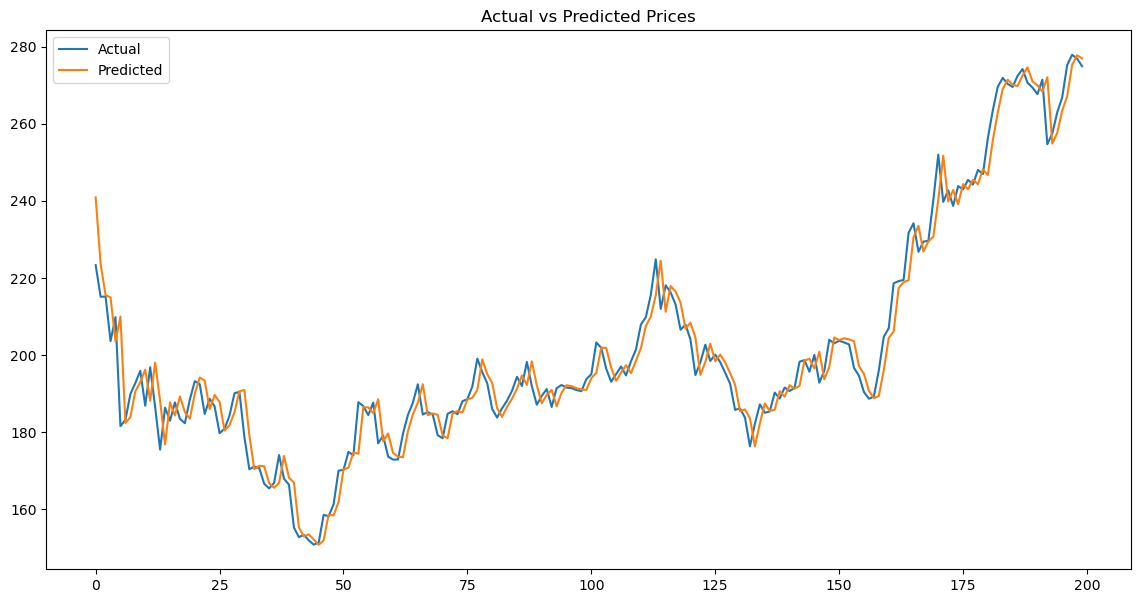

In [37]:
plt.figure(figsize=(14,7))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    predictions[:200],
    label='Predicted'
)

plt.legend()

plt.title(
    "Actual vs Predicted Prices"
)

plt.show()